NAME - SUDHANSHU YADAV

REG NO - 12410114

ROLL NO - 43

COURSE CODE - CAB213

SECTION - D2411(G2)

COURSE NAME - APPLIED AI-COMPUTER VISION AND NATURAL LANGUAGE PROCESSING

PROJECT NAME - Sentiment Analysis Using LSTM

In [1]:
import tensorflow as tf

# Load the IMDB dataset, limiting to the 10,000 most frequent words
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=10000)

# Print the shapes of the training and testing data and labels
print("Training data shape:", train_data.shape)
print("Training labels shape:", train_labels.shape)
print("Testing data shape:", test_data.shape)
print("Testing labels shape:", test_labels.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 57s 3us/step
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 57s 3us/step
Training data shape: (25000,)
Training labels shape: (25000,)
Testing data shape: (25000,)
Testing labels shape: (25000,)
Training data shape: (25000,)
Training labels shape: (25000,)
Testing data shape: (25000,)
Testing labels shape: (25000,)


In [2]:
word_index = tf.keras.datasets.imdb.get_word_index()
print("Number of words in the vocabulary:", len(word_index))

# The first indices are reserved for padding, start-of-sequence, unknown, and unused.
# We need to offset the word indices by 3 (0 for padding, 1 for start, 2 for unknown)
# Some sources say 0 is padding, 1 is start, 2 is unknown, 3 is unused.
# Keras IMDB example uses 3. Let's stick to 3.
# A dictionary mapping words to an integer index

# Create a reverse word index that maps integer indices back to words.
reverse_word_index = dict([(value + 3, key) for (key, value) in word_index.items()])

# Add special tokens to the reverse_word_index
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNKNOWN>"
reverse_word_index[3] = "<UNUSED>"

# Define a decoder function to convert integer sequences back to text
def decode_review(text):
    return ' '.join([reverse_word_index.get(i, '<UNKNOWN>') for i in text])

# Decode and print a sample review (e.g., the first training review)
print("\nSample decoded training review:")
print(decode_review(train_data[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of words in the vocabulary: 88584

Sample decoded training review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNKNOWN> is an amazing actor and now the same being director <UNKNOWN> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNKNOWN> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNKNOWN> to the two little boy's that played the <UNKNOWN> of norman and paul they were just brilliant children are often left out of the <UNKNOWN> list i think b

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define the maximum sequence length
max_len = 256

# Pad the training and testing data
train_data_padded = pad_sequences(train_data, maxlen=max_len, padding='post', truncating='post')
test_data_padded = pad_sequences(test_data, maxlen=max_len, padding='post', truncating='post')

# Print the shapes of the padded data to confirm uniform length
print("Shape of padded training data:", train_data_padded.shape)
print("Shape of padded testing data:", test_data_padded.shape)

Shape of padded training data: (25000, 256)
Shape of padded testing data: (25000, 256)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Vocabulary size is num_words from imdb.load_data, which is 10000
vocabulary_size = 10000

# Embedding dimension
embedding_dim = 128

# LSTM units
lstm_units = 128

# Initialize the Sequential model
model = Sequential()

# Add Embedding layer
model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_len))

# Add LSTM layer
model.add(LSTM(units=lstm_units))

# Add Dense output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Vocabulary size is num_words from imdb.load_data, which is 10000
vocabulary_size = 10000

# Embedding dimension
embedding_dim = 128

# LSTM units
lstm_units = 128

# Initialize the Sequential model
model = Sequential()

# Add Embedding layer, removing the deprecated input_length argument
model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dim))

# Add LSTM layer
model.add(LSTM(units=lstm_units))

# Add Dense output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(train_data_padded, train_labels, epochs=5, batch_size=64, validation_split=0.2)
print("Model training complete.")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 622ms/step - accuracy: 0.5036 - loss: 0.6934 - val_accuracy: 0.5280 - val_loss: 0.6917
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 198s 630ms/step - accuracy: 0.5555 - loss: 0.6822 - val_accuracy: 0.5608 - val_loss: 0.6653
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 193s 616ms/step - accuracy: 0.5865 - loss: 0.6439 - val_accuracy: 0.6724 - val_loss: 0.6182
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 636ms/step - accuracy: 0.7026 - loss: 0.5323 - val_accuracy: 0.8644 - val_loss: 0.3335
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 192s 614ms/step - accuracy: 0.9153 - loss: 0.2288 - val_accuracy: 0.8742 - val_loss: 0.3147
Model training complete.


In [7]:
loss, accuracy = model.evaluate(test_data_padded, test_labels)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step - accuracy: 0.8508 - loss: 0.3507
Test Loss: 0.3512
Test Accuracy: 0.8531


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Make predictions on the test data
predictions = model.predict(test_data_padded)

# Convert probabilities to binary predictions (0 or 1)
binary_predictions = (predictions > 0.5).astype(int)

# Calculate precision, recall, and F1-score
precision = precision_score(test_labels, binary_predictions)
recall = recall_score(test_labels, binary_predictions)
f1 = f1_score(test_labels, binary_predictions)

# Print the results
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-Score: {f1:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 127ms/step
Test Precision: 0.8426
Test Recall: 0.8684
Test F1-Score: 0.8553


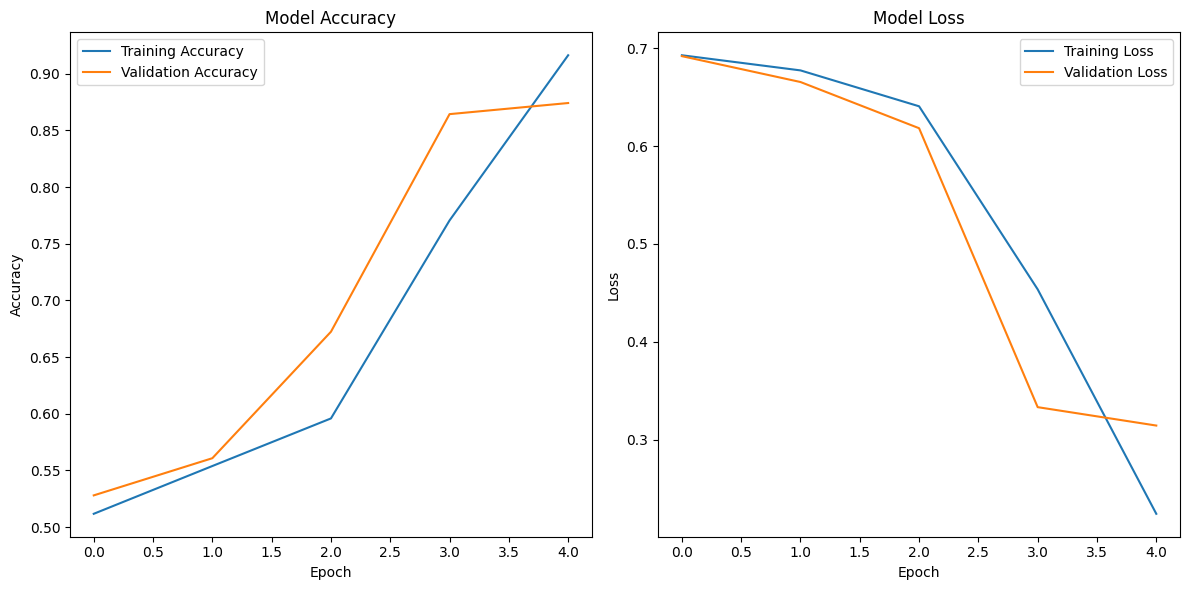

In [9]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Ensure proper spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()

## Summary:

### Data Analysis Key Findings

*   The LSTM model demonstrated good performance on the test dataset, achieving a **Test Accuracy of 0.8531**.
*   The model's classification capability is further supported by a **Test Precision of 0.8426**, a **Test Recall of 0.8684**, and an **F1-Score of 0.8553**.
*   The training history plots for accuracy and loss over epochs were successfully generated, providing visual insights into the model's learning trajectory.

### Insights or Next Steps

*   Analyze the generated training history plots to identify potential overfitting or underfitting, which could inform strategies for model regularization or architecture adjustments.
*   Consider performing error analysis on misclassified instances from the test set to understand the model's weaknesses and specific types of sentiment it struggles with, leading to further model improvements.
